<a href="https://colab.research.google.com/github/uditch2003/my/blob/main/stockprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
#import the data....NOKIA
tickerSymbol='NOK'
data=yf.Ticker(tickerSymbol)
data

yfinance.Ticker object <NOK>

In [ ]:
end_date= datetime.date.today()
start_date=end_date-datetime.timedelta(days=365)
tomorrow=end_date+datetime.timedelta(days=1)
prices=data.history(start=start_date,end=end_date).Close
print(prices)
prices.tail()


Date
2023-11-27 00:00:00-05:00    3.413007
2023-11-28 00:00:00-05:00    3.393724
2023-11-29 00:00:00-05:00    3.432289
2023-11-30 00:00:00-05:00    3.355159
2023-12-01 00:00:00-05:00    3.364800
                               ...   
2024-11-18 00:00:00-05:00    4.460000
2024-11-19 00:00:00-05:00    4.150000
2024-11-20 00:00:00-05:00    4.250000
2024-11-21 00:00:00-05:00    4.130000
2024-11-22 00:00:00-05:00    4.180000
Name: Close, Length: 251, dtype: float64


,Close
Date,
2024-11-18 00:00:00-05:00,4.46
2024-11-19 00:00:00-05:00,4.15
2024-11-20 00:00:00-05:00,4.25
2024-11-21 00:00:00-05:00,4.13
2024-11-22 00:00:00-05:00,4.18


In [ ]:
 #calculate returns
 returns= prices.pct_change().dropna()
 returns

,Close
Date,
2023-11-28 00:00:00-05:00,-0.005650
2023-11-29 00:00:00-05:00,0.011364
2023-11-30 00:00:00-05:00,-0.022472
2023-12-01 00:00:00-05:00,0.002874
2023-12-04 00:00:00-05:00,-0.094556
...,...
2024-11-18 00:00:00-05:00,0.000000
2024-11-19 00:00:00-05:00,-0.069507
2024-11-20 00:00:00-05:00,0.024096


<function matplotlib.pyplot.show(close=None, block=None)>

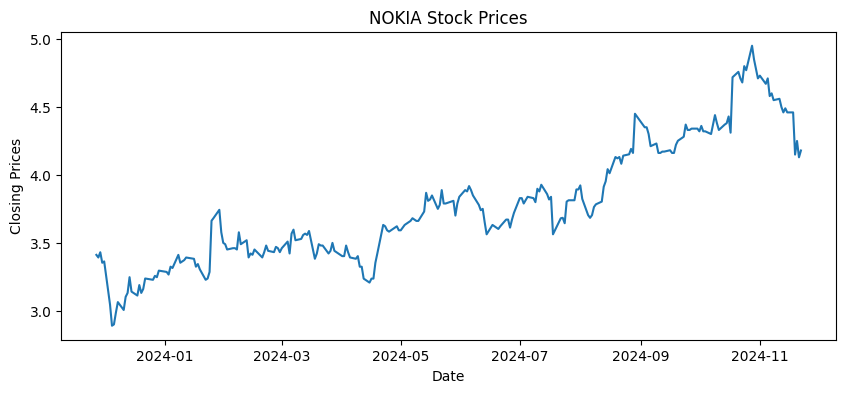

In [ ]:
#plot stock prices
plt.figure(figsize=(10,4))
plt.plot(prices)
plt.title('NOKIA Stock Prices')
plt.ylabel('Closing Prices')
plt.xlabel('Date')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

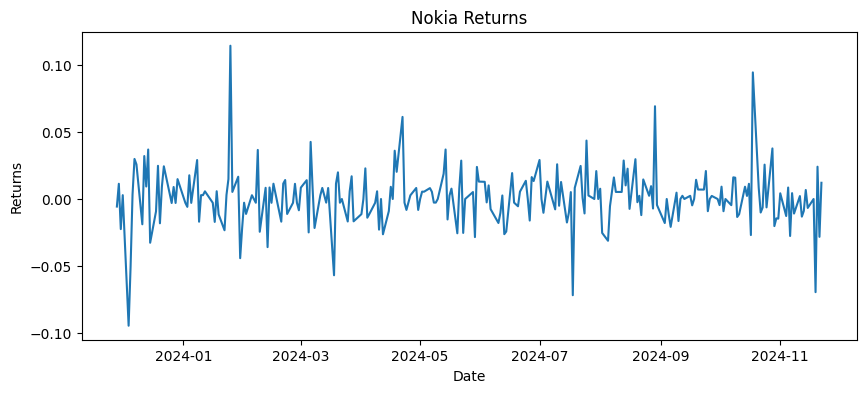

In [ ]:
#plot the returns
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title('Nokia Returns')
plt.ylabel('Returns')
plt.xlabel('Date')
plt.show

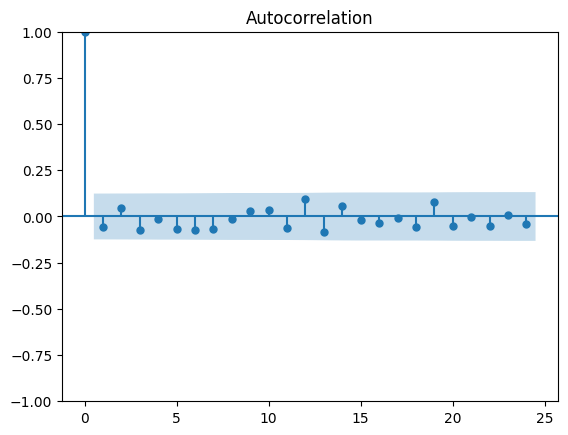

In [ ]:
#plotting acf(MA) and pcf(AR)
plot_acf(returns)
plt.show()

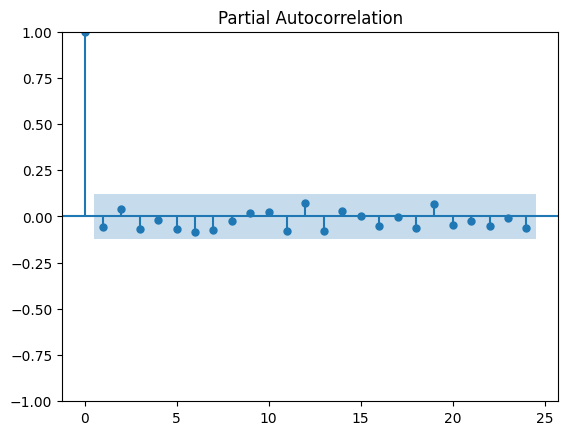

In [ ]:
plot_pacf(returns,method='ywm')
plt.show()

In [ ]:
#building the model of ARIMA
model=ARIMA(prices,order=(7,0,6))
model_fit=model.fit()
model_fit.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(7, 0, 6)   Log Likelihood                 281.427
Date:                Mon, 25 Nov 2024   AIC                           -532.853
Time:                        06:19:16   BIC                           -479.972
Sample:                             0   HQIC                          -511.572
                                - 251                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7760      0.269     14.058      0.000       3.250       4.302
ar.L1         -0.1066      2.405     -0.044      0.965      -4.820       4.607
ar.L2         -0.1105      1.140     -0.097      0.923      -2.345       2.124
ar.L3          0.0744      1.254      0.059      0.953      -2.384       2.532
ar.L4          0.3020      1.076      0.281      0.779      -1.807       2.411
ar.L5          0.2458      0.994      0.247      0.805      -1.702       2.194
ar.L6          0.4537      0.985      0.460      0.645      -1.477       2.385
ar.L7          0.0415      1.715      0.024      0.981      -3.320       3.403
ma.L1          1.0243      2.398      0.427      0.669      -3.675       5.724
ma.L2          1.1812      2.443      0.483      0.629      -3.608       5.970
ma.L3          1.0736      2.958      0.363      0.717      -4.724       6.871
ma.L4          0.8150      2.486      0.328      0.743      -4.058       5.688
ma.L5          0.5341      2.215      0.241      0.809      -3.808       4.876
ma.L6          0.0891      1.703      0.052      0.958      -3.249       3.427
sigma2         0.0061      0.000     18.378      0.000       0.005       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               416.20
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.03   Skew:                             0.42
Prob(H) (two-sided):                  0.88   Kurtosis:                         9.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
#prediction the next day price
next_day_price=model_fit.forecast(100,alpha=0.05)
print(next_day_price)

251    4.145798
252    4.157850
253    4.135333
254    4.153464
255    4.127835
         ...   
346    3.846967
347    3.845718
348    3.844490
349    3.843285
350    3.842100
Name: predicted_mean, Length: 100, dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
predicted_price=next_day_price.values[0]
print(f"The predicted price for {tomorrow} tomorrow:", predicted_price)

The predicted price for 2024-11-26 tomorrow: 4.14579846496616
